# 08 — Descriptive Statistics

**Goal:** Characterize the analytical sample before running regressions. Produces
Table 1 of the thesis and the correlation analysis needed to interpret later results.

**Inputs:**
- `data/panel_monthly.parquet` (81,089 firm-months, for return/sentiment stats)
- `data/panel_yearly.parquet` (6,778 firm-years, for fundamentals/sentiment stats)

**Outputs:**
- `output/table1_summary_stats.csv`
- `output/table_correlations.csv`
- Figures: sentiment distribution, sentiment over time, coverage over time

**Key questions answered:**
- What does the sentiment distribution look like?
- Is sentiment correlated with size, value, momentum, profitability — i.e., is it a
  proxy for already-priced characteristics?
- How does sample composition change across the 2013–2023 window?
- How persistent is firm-level sentiment year-over-year?

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_PROCESSED = Path.home() / "thesis" / "data"
OUTPUT = Path.home() / "thesis" / "output"
OUTPUT.mkdir(exist_ok=True)

panel_monthly = pd.read_parquet(DATA_PROCESSED / "panel_monthly.parquet")
panel_monthly = panel_monthly[(panel_monthly["year"]>=2013)&(panel_monthly["year"]<=2023)].copy()  # 2013-2023 headline window
panel_yearly = pd.read_parquet(DATA_PROCESSED / "panel_yearly.parquet")
panel_yearly = panel_yearly[(panel_yearly["fyear"]>=2013)&(panel_yearly["fyear"]<=2023)].copy()  # 2013-2023 headline window

print(f"Monthly panel: {len(panel_monthly):,} firm-months, {panel_monthly['gvkey'].nunique()} firms")
print(f"Yearly panel:  {len(panel_yearly):,} firm-years, {panel_yearly['gvkey'].nunique()} firms")

Monthly panel: 59,609 firm-months, 626 firms
Yearly panel:  4,962 firm-years, 625 firms


In [2]:
# Variables for Table 1, drawn from the yearly panel (one obs per firm-year)
summary_vars = [
    "sentiment_overall_lag", "n_reviews_lag",
    "roa", "operating_margin", "gross_margin", "sales_growth",
    "log_at", "leverage",
]

# Build the summary table
summary = panel_yearly[summary_vars].describe().T
summary["count"] = panel_yearly[summary_vars].count()
summary = summary[["count", "mean", "50%", "std", "min", "max"]]
summary.columns = ["N", "Mean", "Median", "SD", "Min", "Max"]

# Rename rows to readable labels
label_map = {
    "sentiment_overall_lag": "Employee sentiment (lagged)",
    "n_reviews_lag": "Number of reviews (lagged)",
    "roa": "Return on assets",
    "operating_margin": "Operating margin",
    "gross_margin": "Gross margin",
    "sales_growth": "Sales growth",
    "log_at": "Log total assets",
    "leverage": "Leverage",
}
summary.index = summary.index.map(label_map)

print("Table 1 — Summary Statistics (firm-year panel):")
print(summary.round(3))

summary.round(3).to_csv(OUTPUT / "table1_summary_stats.csv")
print(f"\nSaved to {OUTPUT / 'table1_summary_stats.csv'}")

Table 1 — Summary Statistics (firm-year panel):
                                N        Mean    Median           SD       Min        Max
Employee sentiment (lagged)  4962    3.498406  3.523458     0.476105       1.0        5.0
Number of reviews (lagged)   4962  442.769851     124.0  1445.823656       1.0    38921.0
Return on assets             4962    0.065414  0.055352     0.075436 -0.846056   0.511079
Operating margin             4731    0.251204  0.229512     0.174642 -2.874056   0.815721
Gross margin                 4962    0.447053  0.417102     0.238633 -2.504817   1.108135
Sales growth                 4960    0.081527  0.052998     0.396208 -0.838831  21.991181
Log total assets             4962   10.075925  9.925029      1.31155  6.861638  15.170158
Leverage                     4956    0.653812  0.642778     0.239662  0.031726   3.614536

Saved to /Users/<wrds-username>/thesis/output/table1_summary_stats.csv


In [3]:
# For the correlation analysis we want sentiment alongside firm characteristics
# that are known to predict returns: size, value, profitability, leverage.
# We need book-to-market, which requires market equity — pull from the monthly panel.

# Get year-end market equity per firm-year from the monthly panel
me_yearly = (
    panel_monthly[panel_monthly["month"] == 12]
    [["gvkey", "year", "me"]]
    .rename(columns={"year": "fyear"})
)

# Merge market equity into the yearly panel
corr_data = panel_yearly.merge(me_yearly, on=["gvkey", "fyear"], how="left")

# Construct book-to-market = book equity (seq) / market equity (me)
corr_data["book_to_market"] = corr_data["seq"] / corr_data["me"]

# Variables for the correlation matrix
corr_vars = {
    "sentiment_overall_lag": "Sentiment",
    "log_at": "Size (log assets)",
    "book_to_market": "Book-to-market",
    "roa": "ROA",
    "operating_margin": "Op. margin",
    "leverage": "Leverage",
    "sales_growth": "Sales growth",
    "n_reviews_lag": "N reviews",
}

corr_matrix = corr_data[list(corr_vars.keys())].rename(columns=corr_vars).corr()

print("Correlation matrix:")
print(corr_matrix.round(3))
print()

# The row that matters most: how does sentiment correlate with everything else?
print("Sentiment's correlation with firm characteristics:")
sentiment_corr = corr_matrix["Sentiment"].drop("Sentiment").sort_values(key=abs, ascending=False)
print(sentiment_corr.round(3))

corr_matrix.round(3).to_csv(OUTPUT / "table_correlations.csv")
print(f"\nSaved to {OUTPUT / 'table_correlations.csv'}")

Correlation matrix:
                   Sentiment  Size (log assets)  Book-to-market    ROA  Op. margin  Leverage  Sales growth  N reviews
Sentiment              1.000              0.096          -0.117  0.099       0.045    -0.021         0.073      0.087
Size (log assets)      0.096              1.000           0.429 -0.302       0.146     0.221        -0.006      0.253
Book-to-market        -0.117              0.429           1.000 -0.401       0.016    -0.153        -0.039     -0.044
ROA                    0.099             -0.302          -0.401  1.000       0.309    -0.070         0.136      0.032
Op. margin             0.045              0.146           0.016  0.309       1.000     0.006         0.107     -0.039
Leverage              -0.021              0.221          -0.153 -0.070       0.006     1.000        -0.046      0.068
Sales growth           0.073             -0.006          -0.039  0.136       0.107    -0.046         1.000     -0.006
N reviews              0.087        

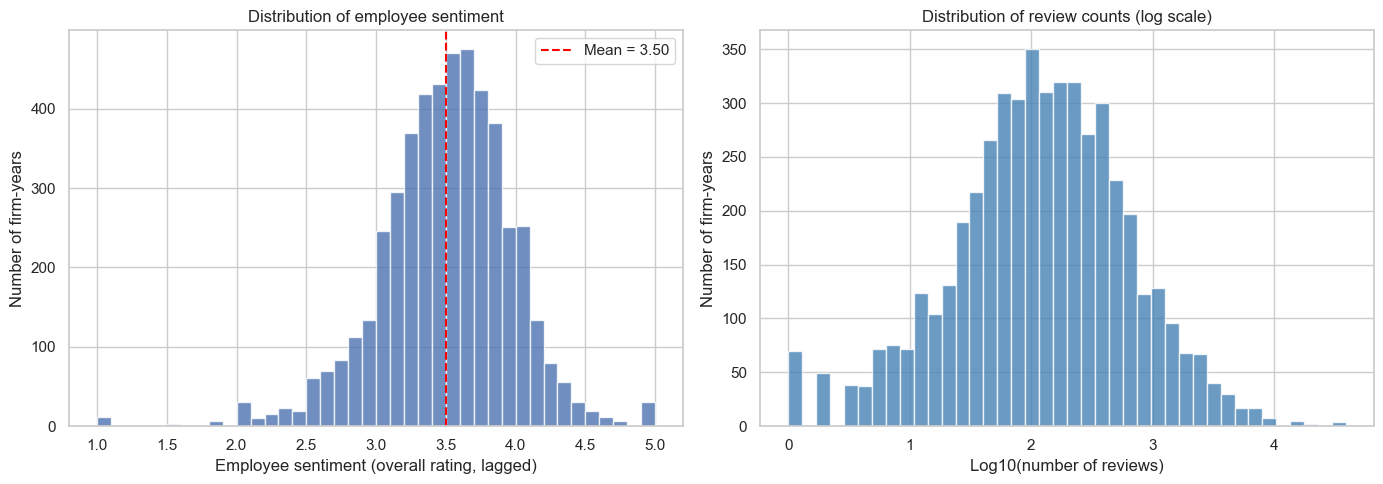

Saved figure to /Users/<wrds-username>/thesis/output/fig_sentiment_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of lagged sentiment
axes[0].hist(panel_yearly["sentiment_overall_lag"].dropna(), bins=40,
             edgecolor="white", alpha=0.8)
axes[0].axvline(panel_yearly["sentiment_overall_lag"].mean(),
                color="red", linestyle="--", label=f"Mean = {panel_yearly['sentiment_overall_lag'].mean():.2f}")
axes[0].set_xlabel("Employee sentiment (overall rating, lagged)")
axes[0].set_ylabel("Number of firm-years")
axes[0].set_title("Distribution of employee sentiment")
axes[0].legend()

# Right: distribution of review counts (log scale, given the skew)
axes[1].hist(np.log10(panel_yearly["n_reviews_lag"].dropna()), bins=40,
             edgecolor="white", alpha=0.8, color="steelblue")
axes[1].set_xlabel("Log10(number of reviews)")
axes[1].set_ylabel("Number of firm-years")
axes[1].set_title("Distribution of review counts (log scale)")

plt.tight_layout()
plt.savefig(OUTPUT / "fig_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {OUTPUT / 'fig_sentiment_distribution.png'}")

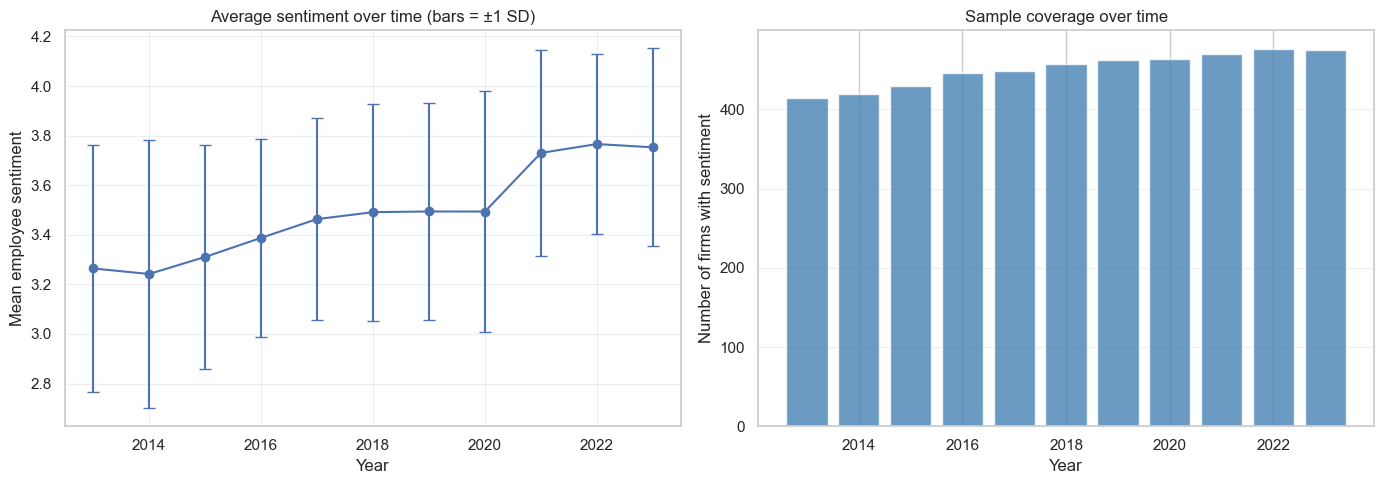

Mean sentiment by year:
        mean    std
fyear              
2013   3.264  0.498
2014   3.242  0.541
2015   3.311  0.453
2016   3.388  0.399
2017   3.463  0.408
2018   3.491  0.437
2019   3.494  0.437
2020   3.494  0.487
2021    3.73  0.416
2022   3.766  0.363
2023   3.753  0.399


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean sentiment by year (with error bars showing dispersion)
yearly_sent = panel_yearly.groupby("fyear")["sentiment_overall_lag"].agg(["mean", "std"])
axes[0].errorbar(yearly_sent.index, yearly_sent["mean"], yerr=yearly_sent["std"],
                 marker="o", capsize=4, capthick=1)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean employee sentiment")
axes[0].set_title("Average sentiment over time (bars = ±1 SD)")
axes[0].grid(True, alpha=0.3)

# Right: number of firms with sentiment data by year
yearly_coverage = panel_yearly.groupby("fyear")["gvkey"].nunique()
axes[1].bar(yearly_coverage.index, yearly_coverage.values, alpha=0.8, color="steelblue")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of firms with sentiment")
axes[1].set_title("Sample coverage over time")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUTPUT / "fig_sentiment_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

print("Mean sentiment by year:")
print(yearly_sent.round(3))

In [6]:
# How persistent is firm-level sentiment? Correlate each firm's sentiment with its own
# prior-year sentiment. High persistence = sentiment is a stable firm trait.
# Low persistence = sentiment is noisy or changes rapidly.

persist = panel_yearly[["gvkey", "fyear", "sentiment_overall_lag"]].copy()
persist = persist.sort_values(["gvkey", "fyear"])
# FIX 2026-07-12: positional shift(1) replaced with a fiscal-year merge, so a
# firm's "prior-year" sentiment across a membership gap is not a stale value
# from an older year.
_pr = persist[["gvkey", "fyear", "sentiment_overall_lag"]].copy()
_pr["fyear"] = _pr["fyear"] + 1
persist = persist.merge(_pr.rename(columns={"sentiment_overall_lag": "sentiment_prior"}),
                        on=["gvkey", "fyear"], how="left", validate="m:1")

# Correlation between this year's and last year's sentiment
valid = persist.dropna(subset=["sentiment_overall_lag", "sentiment_prior"])
persistence_corr = valid["sentiment_overall_lag"].corr(valid["sentiment_prior"])

print(f"Year-over-year sentiment persistence (autocorrelation): {persistence_corr:.3f}")
print(f"  Based on {len(valid):,} firm-year pairs")
print()

# Within-firm vs between-firm variation: proper ANOVA decomposition of sentiment
# (how much of its variation is across firms vs within a firm over time)
_s = panel_yearly.dropna(subset=["sentiment_overall_lag"]); _gm = _s["sentiment_overall_lag"].mean()
_fm = _s.groupby("gvkey")["sentiment_overall_lag"].transform("mean")
_bss = ((_fm-_gm)**2).sum(); _wss = ((_s["sentiment_overall_lag"]-_fm)**2).sum()
print(f"Variance decomposition (ANOVA): within-firm {100*_wss/(_bss+_wss):.1f}%, across-firm {100*_bss/(_bss+_wss):.1f}%")

Year-over-year sentiment persistence (autocorrelation): 0.629
  Based on 4,314 firm-year pairs

Variance decomposition (ANOVA): within-firm 49.7%, across-firm 50.3%
